In [1]:
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("research_grade_6g_synthetic_dataset_10000.csv")

In [3]:
ACTIVE_USERS = 50

df = df.sample(ACTIVE_USERS, random_state=42).reset_index(drop=True)

df.head()

,User_ID,Base_Station_ID,Channel_ID,Distance_m,Carrier_Freq_GHz,Path_Loss_dB,Beamforming_Gain_dB,Tx_Power_W,Rx_Power_dBm,Interference_dBm,...,Network_Load,Packet_Size_MB,Throughput_Mbps,Latency_ms,Energy_J,Cost,User_Speed_kmph,Packet_Loss_%,QoS_Class,Priority
0,6253,1,5,491.62,6.0,98.79,14.65,0.626,-26.18,-88.69,...,0.294,1.85,103.61,2.42,0.089,0.565,77.3,0.0,eMBB,Low
1,4685,3,2,380.58,3.5,95.26,7.64,0.318,-32.59,-102.03,...,0.605,7.77,111.79,3.86,0.177,0.413,118.0,0.0,URLLC,High
2,1732,4,8,351.13,6.0,97.65,9.02,0.626,-30.66,-105.37,...,0.403,1.97,235.72,2.57,0.042,0.814,15.0,0.0,eMBB,High
3,4743,1,5,459.97,28.0,110.15,8.77,1.931,-38.52,-85.10,...,0.488,6.48,154.56,2.98,0.648,1.479,71.0,0.0,eMBB,Medium
4,4522,1,7,338.72,3.5,83.37,9.20,1.933,-11.30,-88.24,...,0.219,8.01,127.60,2.20,0.971,1.236,114.4,0.0,eMBB,Low


In [4]:
cols = [
    "Throughput_Mbps",
    "Energy_J",
    "Latency_ms",
    "Cost",
    "Allocated_BW_MHz"
]

scaler = MinMaxScaler()

df[cols] = scaler.fit_transform(df[cols])

In [5]:


MAX_POWER = 20

TOTAL_BW = 100

TOTAL_RB = 275

MIN_SINR = 10

MAX_LATENCY = 10

throughput_threshold = {
    "mMTC":2,
    "URLLC":20,
    "eMBB":100
}

df["Min_Throughput"] = df["QoS_Class"].map(throughput_threshold)

In [6]:
NUM_ANTS = 30

MAX_ITER = 100

ALPHA = 1

BETA = 2

EVAPORATION = 0.4

Q = 100

In [7]:
NUM_CHANNELS = 8

pheromone = np.ones((ACTIVE_USERS, NUM_CHANNELS))

In [8]:
NUM_CHANNELS = 8

pheromone = np.ones((ACTIVE_USERS, NUM_CHANNELS))

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Normalize SINR to [0, 1]
scaler = MinMaxScaler()

sinr = scaler.fit_transform(df[["SINR_dB"]]).flatten()

# Avoid exact zeros
sinr = sinr + 1e-6

# Create heuristic matrix
heuristic = np.tile(
    sinr.reshape(-1, 1),
    (1, NUM_CHANNELS)
)

In [20]:
def construct_solution():

    solution=[]

    for user in range(ACTIVE_USERS):

        tau = pheromone[user]**ALPHA

        eta = heuristic[user]**BETA

        prob = tau * eta

# Ensure probabilities are non-negative
        prob = np.maximum(prob, 1e-12)

# Normalize so they sum to 1
        prob = prob / prob.sum()

        channel = np.random.choice(
    NUM_CHANNELS,
    p=prob
)

        solution.append(channel)

    return solution

In [17]:
def fitness(solution):

    throughput = df["Throughput_Mbps"].mean()

    energy = df["Energy_J"].mean()

    latency = df["Latency_ms"].mean()

    cost = df["Cost"].mean()

    bw = df["Allocated_BW_MHz"].mean()

    score = (
        0.35*throughput
        -0.25*energy
        -0.20*latency
        -0.10*cost
        +0.10*bw
    )

    penalty = 0

    if df["Tx_Power_W"].sum()>MAX_POWER:

        penalty +=100

    if df["Allocated_BW_MHz"].sum()>TOTAL_BW:

        penalty +=100

    if (df["SINR_dB"]<MIN_SINR).any():

        penalty +=100

    if (df["Latency_ms"]>MAX_LATENCY).any():

        penalty +=100

    return score-penalty

In [18]:
def update_pheromone(pheromone, solutions, scores):

    pheromone *= (1-EVAPORATION)

    for sol,score in zip(solutions,scores):

        for user,channel in enumerate(sol):

            pheromone[user][channel] += score/Q

    return pheromone

In [21]:
best_score = -1e9

best_solution = None

history=[]

for iteration in range(MAX_ITER):

    solutions=[]

    scores=[]

    for ant in range(NUM_ANTS):

        sol = construct_solution()

        score = fitness(sol)

        solutions.append(sol)

        scores.append(score)

        if score>best_score:

            best_score=score

            best_solution=sol

    pheromone = update_pheromone(
        pheromone,
        solutions,
        scores
    )

    history.append(best_score)

In [22]:
print("Best Fitness :",best_score)

print("Average Throughput :",df["Throughput_Mbps"].mean())

print("Average Energy :",df["Energy_J"].mean())

print("Average Latency :",df["Latency_ms"].mean())

print("Average Cost :",df["Cost"].mean())

Best Fitness : -100.05028381245374
Average Throughput : 0.29306591440759594
Average Energy : 0.14985406532314105
Average Latency : 0.5083790523690773
Average Cost : 0.43050889025137956


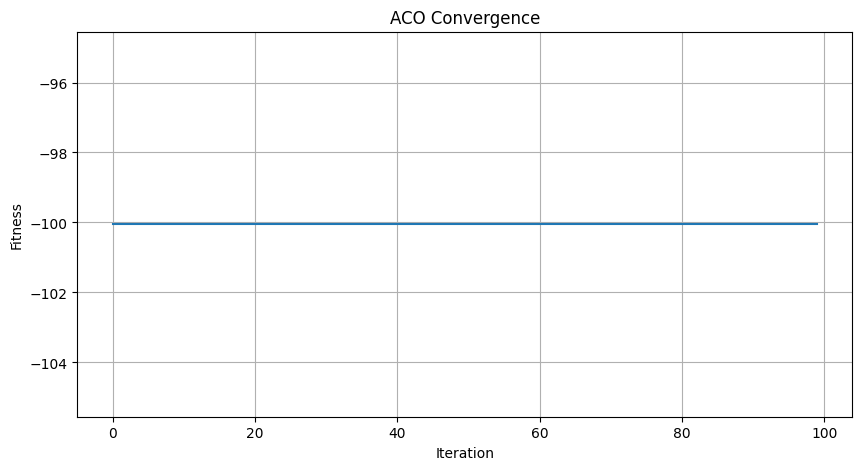

In [23]:
plt.figure(figsize=(10,5))

plt.plot(history)

plt.xlabel("Iteration")

plt.ylabel("Fitness")

plt.title("ACO Convergence")

plt.grid(True)

plt.show()

In [24]:
allocation = pd.DataFrame({
    "User": range(ACTIVE_USERS),
    "Assigned_Channel": best_solution
})

allocation.head()

,User,Assigned_Channel
0,0,4
1,1,7
2,2,4
3,3,6
4,4,3
